In [1]:
import numpy as np
import pandas as pd
import scipy
from scipy import stats
import suncalc

import dask.dataframe as dd
from pathlib import Path
from tqdm import tqdm
import re
import pytz

import datetime as dt

import matplotlib.pyplot as plt
from matplotlib import colors
import soundfile as sf
import matplotlib.patches as patches

In [2]:
import sys

sys.path.append("../src")
sys.path.append("../src/activity")

In [3]:
import subsampling as ss
import activity_assembly as actvt
import bout.assembly as bt
import comparison.data_assembly as comp
import comparison.plot as complot
from core import SITE_NAMES

from cli import get_file_paths
import plot
import pipeline

In [4]:
dt_starts = {'Carp high':dt.datetime(2022, 7, 15, 3, 0, 0),
           'Telephone high':dt.datetime(2022, 8, 19, 3, 0, 0)}
dt_ends = {'Carp high':dt.datetime(2022, 8, 15, 13, 0, 0),
           'Telephone high':dt.datetime(2022, 9, 19, 13, 0, 0)}
high_activity_types = {'Carp':'LF', 'Telephone':'HF'}
low_activity_types = {'Carp':'HF', 'Telephone':'LF'}
activity_types = {'high':high_activity_types, 'low':low_activity_types}

In [5]:
avail = np.arange(0, 180, 2) + 2
reset_3 = avail[np.where((3*60 % avail) == 0)[0]]
reset_4 = avail[np.where((4*60 % avail) == 0)[0]]
reset_6 = avail[np.where((6*60 % avail) == 0)[0]]
reset_12 = avail[np.where((12*60 % avail) == 0)[0]]
reset_24 = avail[np.where((24*60 % avail) == 0)[0]]

In [6]:
step = 1/6
step_by = np.arange(0, (3/6)+step, step)
step_by = step_by[step_by>=(1/6)]
step_by

array([0.16666667, 0.33333333, 0.5       ])

In [7]:
cycle_lengths = [6, 10, 30]
percent_ons = step_by
data_params = dict()
data_params["cycle_lengths"] = cycle_lengths
data_params["percent_ons"] = percent_ons
dc_tags = ss.get_list_of_dc_tags(cycle_lengths, percent_ons)
dc_tags

['30of30',
 '1of6',
 '2of6',
 '3of6',
 '2of10',
 '3of10',
 '5of10',
 '5of30',
 '10of30',
 '15of30']

In [8]:
site_keys = ['Carp']
type_keys = ['LF']
data_params["dc_tags"] = dc_tags
data_params['cur_dc_tag'] = '30of30'
data_params['recording_start'] = '00:00'
data_params['recording_end'] = '16:00'
data_params['assembly_type'] = 'kmeans'
site_key = site_keys[0]
type_key = type_keys[0]
actvt_key = 'high'
type_key = activity_types[actvt_key][site_key]
data_params['start'] = dt_starts[f'{site_key} {actvt_key}']
data_params['end'] = dt_ends[f'{site_key} {actvt_key}']
data_params['P'] = 0.4
data_params['upb'] = 1

In [9]:
def add_noise_to_group(group, frac):
    noise_df = pd.DataFrame()
    noise_start_times = np.random.uniform(0, 1800, np.floor(frac*group.shape[0]).astype(int))
    noise_df['start_time'] = noise_start_times
    noise_df['end_time'] = noise_start_times + 0.01
    noise_df['low_freq'] = [24000]*noise_df.shape[0]
    noise_df['high_freq'] = [80000]*noise_df.shape[0]
    noise_df['class'] = ['NOISE']*noise_df.shape[0]

    added_noise_file_dets = pd.concat([group, noise_df])
    if frac == 0:
        assert(len(noise_df)==0)
        assert (added_noise_file_dets['call_start_time'].equals(group['call_start_time']))
    file_dts = pd.to_datetime(added_noise_file_dets['input_file'], format='%Y%m%d_%H%M%S', exact=False).ffill().bfill()

    anchor_start_times = file_dts + pd.to_timedelta(added_noise_file_dets['start_time'].values.astype('float64'), unit='S')
    anchor_end_times = file_dts + pd.to_timedelta(added_noise_file_dets['end_time'].values.astype('float64'), unit='S') 
    added_noise_file_dets['call_end_time'] = anchor_end_times
    added_noise_file_dets['call_start_time'] = anchor_start_times
    added_noise_file_dets['ref_time'] = anchor_start_times
    added_noise_file_dets = added_noise_file_dets.sort_values(by='call_start_time')

    return added_noise_file_dets

def generate_activity_btp_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    btp_mod_columns = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
    bout_params = bt.get_bout_params_from_location(location_df, data_params)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    btp_cont_column = comp.get_continuous_btp_partitioned_for_dc_scheme(metric_col_name, location_df.copy(), data_params, bout_params)
    fractions = np.arange(0.0, 0.51, 0.05)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        time_on_in_mins = int(data_params['cur_dc_tag'].split('of')[0])
        time_on_in_secs = (60*time_on_in_mins)

        added_noise_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : add_noise_to_group(x, frac))
        dc_applied_df = ss.simulate_dutycycle_on_detections(added_noise_location_df.copy(), data_params)
        dc_applied_df['freq_group'] = [data_params['type_tag']]*dc_applied_df.shape[0]
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df, location_df)
        bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dc_applied_df, data_params, bout_params)
        bout_duration = actvt.get_bout_duration_per_cycle(bout_metrics, cycle_length_in_mins)
        bout_time_percentage = actvt.get_btp_per_time_on(bout_duration, time_on_in_secs)
        data_params['cur_dc_tag'] = f'{round(frac, 2)}'
        bout_time_percentage_modified = actvt.filter_and_prepare_metric(bout_time_percentage, data_params)
        bout_time_percentage_modified = bout_time_percentage_modified.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df, bout_time_percentage_modified, cycle_length_in_mins, data_params)

        btp_mod_columns = pd.concat([btp_mod_columns, bout_time_percentage_modified], axis=1)

    if save:
        btp_mod_columns.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_btp_TYPE_SITE_summary"]}.csv')
        btp_cont_column.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_btp_TYPE_SITE_summary"]}.csv')

    return btp_mod_columns, btp_cont_column


def generate_activity_call_rate_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    activity_arr = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    callrate_arr = comp.get_continuous_call_rates_partitioned_for_dc_scheme(metric_col_name, file_paths, data_params)
    fractions = np.arange(0.0, 0.51, 0.05)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        time_on_in_mins = int(data_params['cur_dc_tag'].split('of')[0])

        added_noise_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : add_noise_to_group(x, frac))
        dc_applied_df = ss.simulate_dutycycle_on_detections(added_noise_location_df.copy(), data_params)
        dc_applied_df['freq_group'] = [data_params['type_tag']]*dc_applied_df.shape[0]
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df, location_df)
        num_of_detections = actvt.get_number_of_detections_per_cycle(dc_applied_df, cycle_length_in_mins)        
        call_rate = actvt.get_metric_per_time_on(num_of_detections, time_on_in_mins)
        data_params['cur_dc_tag'] = f'{round(frac, 2)}'
        call_rate_dc_column = actvt.filter_and_prepare_metric(call_rate, data_params)
        call_rate_dc_column = call_rate_dc_column.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df, call_rate_dc_column, cycle_length_in_mins, data_params)
        
        activity_arr = pd.concat([activity_arr, call_rate_dc_column], axis=1)

    if save:
        activity_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_callrate_TYPE_SITE_summary"]}.csv')
        callrate_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_callrate_TYPE_SITE_summary"]}.csv')

    return activity_arr, callrate_arr


def generate_activity_index_percent_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    activity_arr = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    actvtind_cont_column = comp.get_continuous_activity_index_partitioned_for_dc_scheme(metric_col_name, file_paths, data_params)
    fractions = np.arange(0.0, 0.51, 0.05)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        data_params['time_on_in_secs'] = int(data_params['cur_dc_tag'].split('of')[0]) * 60

        added_noise_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : add_noise_to_group(x, frac))
        dc_applied_df = ss.simulate_dutycycle_on_detections(added_noise_location_df.copy(), data_params)
        dc_applied_df['freq_group'] = [data_params['type_tag']]*dc_applied_df.shape[0]
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df, location_df)
        num_blocks_of_presence = actvt.get_activity_index_per_cycle(dc_applied_df, data_params)        
        activity_ind_percent = actvt.get_activity_index_per_time_on_index(num_blocks_of_presence, data_params)
        data_params['cur_dc_tag'] = f'{round(frac, 2)}'
        ind_percent_dc_column = actvt.filter_and_prepare_metric(activity_ind_percent, data_params)
        ind_percent_dc_column = ind_percent_dc_column.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df, ind_percent_dc_column, cycle_length_in_mins, data_params)
        
        activity_arr = pd.concat([activity_arr, ind_percent_dc_column], axis=1)

    if save:
        activity_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_mod_actind_TYPE_SITE_summary"]}.csv')
        actvtind_cont_column.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fp_error_base_actind_TYPE_SITE_summary"]}.csv')

    return activity_arr, actvtind_cont_column

In [10]:
dc_tag = '15of30'
print(site_key, type_key, dc_tag)
data_params['metric_tag'] = 'bout_time_percentage'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitybout_arr_fp, btp_arr_fp = generate_activity_btp_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 15of30


100%|██████████| 11/11 [01:49<00:00,  9.93s/it]


In [11]:
print(site_key, type_key, dc_tag)
data_params['metric_tag'] = 'call_rate'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fp, callrate_arr_fp = generate_activity_call_rate_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 15of30


100%|██████████| 11/11 [01:00<00:00,  5.54s/it]


In [12]:
print(site_key, type_key, dc_tag)
data_params['metric_tag'] = 'activity_index'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
data_params['index_time_block_in_secs'] = 5
file_paths = get_file_paths(data_params)

activityind_arr_fp, actvtind_arr_fp = generate_activity_index_percent_for_false_positives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 15of30


100%|██████████| 11/11 [01:00<00:00,  5.54s/it]


In [13]:
def removed_calls_from_group(group, frac):
    group_reduced = group.sample(frac=frac).sort_values(by='call_start_time')
    if frac == 0:
        assert (group_reduced.equals(group))
    return group_reduced

def generate_activity_btp_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    btp_mod_columns = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)
    bout_params = bt.get_bout_params_from_location(location_df, data_params)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    btp_cont_column = comp.get_continuous_btp_partitioned_for_dc_scheme(metric_col_name, location_df.copy(), data_params, bout_params)
    fractions = np.arange(1.0, 0.49, -0.05)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        time_on_in_mins = int(data_params['cur_dc_tag'].split('of')[0])
        time_on_in_secs = (60*time_on_in_mins)

        removed_calls_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : removed_calls_from_group(x, frac))
        dc_applied_df_reduced = ss.simulate_dutycycle_on_detections(removed_calls_location_df.copy(), data_params)
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df_reduced, location_df)
        bout_metrics = bt.generate_bout_metrics_for_location_and_freq(dc_applied_df_reduced, data_params, bout_params)
        bout_duration = actvt.get_bout_duration_per_cycle(bout_metrics, cycle_length_in_mins)
        bout_time_percentage = actvt.get_btp_per_time_on(bout_duration, time_on_in_secs)
        data_params['cur_dc_tag'] = f'{round(frac, 2)}'
        bout_time_percentage_dc_column = actvt.filter_and_prepare_metric(bout_time_percentage, data_params)
        bout_time_percentage_dc_column = bout_time_percentage_dc_column.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df_reduced, bout_time_percentage_dc_column, cycle_length_in_mins, data_params)

        btp_mod_columns = pd.concat([btp_mod_columns, bout_time_percentage_dc_column], axis=1)

    if save:
        btp_mod_columns.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_btp_TYPE_SITE_summary"]}.csv')
        btp_cont_column.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_btp_TYPE_SITE_summary"]}.csv')

    return btp_mod_columns, btp_cont_column


def generate_activity_call_rate_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    activity_arr = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    callrate_arr = comp.get_continuous_call_rates_partitioned_for_dc_scheme(metric_col_name, file_paths, data_params)
    fractions = np.arange(1.0, 0.49, -0.05)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        time_on_in_mins = int(data_params['cur_dc_tag'].split('of')[0])

        removed_calls_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : removed_calls_from_group(x, frac))
        dc_applied_df_reduced = ss.simulate_dutycycle_on_detections(removed_calls_location_df.copy(), data_params)
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df_reduced, location_df)
        num_of_detections = actvt.get_number_of_detections_per_cycle(dc_applied_df_reduced, cycle_length_in_mins)        
        call_rate = actvt.get_metric_per_time_on(num_of_detections, time_on_in_mins)
        data_params['cur_dc_tag'] = f'{round(frac, 2)}'
        call_rate_dc_column = actvt.filter_and_prepare_metric(call_rate, data_params)
        call_rate_dc_column = call_rate_dc_column.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df_reduced, call_rate_dc_column, cycle_length_in_mins, data_params)
        
        activity_arr = pd.concat([activity_arr, call_rate_dc_column], axis=1)

    if save:
        activity_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_callrate_TYPE_SITE_summary"]}.csv')
        callrate_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_callrate_TYPE_SITE_summary"]}.csv')

    return activity_arr, callrate_arr


def generate_activity_index_percent_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=False):
    activity_arr = pd.DataFrame()
    location_df = pd.read_csv(f'{file_paths["SITE_folder"]}/{file_paths["detector_TYPE_SITE_YEAR"]}.csv', low_memory=False, index_col=0)

    metric_col_name = f'{data_params["metric_tag"]} ({dc_tag})'
    actvtind_cont_column = comp.get_continuous_activity_index_partitioned_for_dc_scheme(metric_col_name, file_paths, data_params)
    fractions = np.arange(1.0, 0.49, -0.05)
    for i in tqdm(range(len(fractions))):
        frac = fractions[i]
        data_params['cur_dc_tag'] = dc_tag
        cycle_length_in_mins = int(data_params['cur_dc_tag'].split('of')[1])
        data_params['time_on_in_secs'] = int(data_params['cur_dc_tag'].split('of')[0]) * 60

        removed_calls_location_df = location_df.groupby(by='input_file_dt', group_keys=False).apply(lambda x : removed_calls_from_group(x, frac))
        dc_applied_df_reduced = ss.simulate_dutycycle_on_detections(removed_calls_location_df.copy(), data_params)
        # comp.does_duty_cycled_df_have_less_dets_than_original(dc_applied_df_reduced, location_df)
        num_blocks_of_presence = actvt.get_activity_index_per_cycle(dc_applied_df_reduced, data_params)        
        activity_ind_percent = actvt.get_activity_index_per_time_on_index(num_blocks_of_presence, data_params)
        data_params['cur_dc_tag'] = f'{round(frac, 2)}'
        ind_percent_dc_column = actvt.filter_and_prepare_metric(activity_ind_percent, data_params)
        ind_percent_dc_column = ind_percent_dc_column.set_index("datetime_UTC")
        ss.are_there_expected_number_of_cycles(dc_applied_df_reduced, ind_percent_dc_column, cycle_length_in_mins, data_params)
        
        activity_arr = pd.concat([activity_arr, ind_percent_dc_column], axis=1)

    if save:
        activity_arr.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_mod_actind_TYPE_SITE_summary"]}.csv')
        actvtind_cont_column.to_csv(f'{file_paths["duty_cycled_folder"]}/dc{dc_tag}_{file_paths["fn_error_base_actind_TYPE_SITE_summary"]}.csv')

    return activity_arr, actvtind_cont_column

In [14]:
print(site_key, type_key, dc_tag)
data_params['metric_tag'] = 'bout_time_percentage'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitybout_arr_fn, btp_arr_fn = generate_activity_btp_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 15of30


100%|██████████| 11/11 [01:01<00:00,  5.61s/it]


In [15]:
print(site_key, type_key, dc_tag)
data_params['metric_tag'] = 'call_rate'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activitycallrate_arr_fn, callrate_arr_fn = generate_activity_call_rate_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 15of30


100%|██████████| 11/11 [00:24<00:00,  2.23s/it]


In [16]:
print(site_key, type_key, dc_tag)
data_params['metric_tag'] = 'activity_index'
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

activityind_arr_fn, actvtind_arr_fn = generate_activity_index_percent_for_false_negatives_investigation_for_dc_tag(data_params, file_paths, dc_tag, save=True)

Carp LF 15of30


100%|██████████| 11/11 [00:24<00:00,  2.26s/it]


In [ ]:
activitybout_arr_fp['bout_time_percentage (0.0)']

datetime_UTC
2022-07-13 05:00:00     2.176378
2022-07-13 05:30:00     7.410056
2022-07-13 06:00:00     3.461478
2022-07-13 06:30:00     0.825856
2022-07-13 07:00:00    10.091956
                         ...    
2022-10-17 11:30:00     0.000000
2022-10-17 12:00:00     0.000000
2022-10-17 12:30:00     0.000000
2022-10-17 13:00:00     0.000000
2022-10-17 13:30:00     2.022267
Name: bout_time_percentage (0.0), Length: 3090, dtype: float64

In [156]:
data_params["dc_tags"] = ['30of30', '15of30']
data_params['cur_dc_tag'] = '30of30'
data_params['metric_tag'] = 'bout_time_percentage'
data_params['recording_start'] = '00:00'
data_params['recording_end'] = '16:00'
data_params['assembly_type'] = 'kmeans'

print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

btp_arr_dc, btp_arr_cont = comp.generate_activity_btp_for_dc_schemes_and_cont(data_params, file_paths, save=False)

Carp LF


100%|██████████| 1/1 [00:15<00:00, 15.39s/it]


In [157]:
data_params['metric_tag'] = 'call_rate'
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

callrate_arr_dc, callrate_arr_cont = comp.generate_activity_call_rate_for_dc_schemes_and_cont(data_params, file_paths, save=False)

Carp LF


100%|██████████| 1/1 [00:06<00:00,  6.65s/it]


In [158]:
data_params['metric_tag'] = 'activity_index'
data_params['index_time_block_in_secs'] = 5

print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params["detector_tag"] = 'bd2'
file_paths = get_file_paths(data_params)

actvtind_arr_dc, actvtind_arr_cont = comp.generate_activity_index_percent_for_dc_schemes_and_cont(data_params, file_paths, save=False)

Carp LF


100%|██████████| 1/1 [00:06<00:00,  6.16s/it]


In [159]:
dc_arr = btp_arr_dc['bout_time_percentage (15of30)'].dropna()
fp_arr = activitybout_arr_fp['bout_time_percentage (0.0)'].dropna()
fn_arr = activitybout_arr_fn['bout_time_percentage (1.0)'].dropna()
(dc_arr.equals(fp_arr))&(dc_arr.equals(fn_arr))

True

In [160]:
dc_arr = btp_arr_cont.dropna()
fp_arr = btp_arr_fp.dropna()
fn_arr = btp_arr_fn.dropna()
(dc_arr.equals(fp_arr))&(dc_arr.equals(fn_arr))

True

In [161]:
dc_arr = callrate_arr_dc['call_rate (15of30)']
fp_arr = activitycallrate_arr_fp['call_rate (0.0)'].dropna()
fn_arr = activitycallrate_arr_fn['call_rate (1.0)'].dropna()
(dc_arr.equals(fp_arr))&(dc_arr.equals(fn_arr))

True

In [162]:
dc_arr = callrate_arr_cont
fp_arr = callrate_arr_fp.dropna()
fn_arr = callrate_arr_fn.dropna()
(dc_arr.equals(fp_arr))&(dc_arr.equals(fn_arr))

True

In [163]:
dc_arr = actvtind_arr_dc['activity_index (15of30)']
fp_arr = activityind_arr_fp['activity_index (0.0)'].dropna()
fn_arr = activityind_arr_fn['activity_index (1.0)'].dropna()
(dc_arr.equals(fp_arr))&(dc_arr.equals(fn_arr))

True

In [164]:
def get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb):
    points_dc = pd.DataFrame(plt_dcmetr.values, columns=['values'], index=plt_dcmetr.index)
    points_c = pd.DataFrame(plt_cmetr.values, columns=['values'], index=plt_cmetr.index)
    points_c = points_c[points_c!=0].dropna()
    points_dc = points_dc.loc[points_c.index]
    total_num_points = points_dc.shape[0]

    axis = 1
    within_bounds = ((points_dc.values<=points_c.values*(axis+(upb*p)))&(points_dc.values>=points_c.values*(axis-p)))
    num_points_in_bounds = np.sum(within_bounds.astype(int), axis=0)
    percent_points_in_bounds = num_points_in_bounds / total_num_points
    all_points_bound = p[percent_points_in_bounds==1][0]

    test_true_100_at_factor(points_dc, points_c, all_points_bound)

    return percent_points_in_bounds

def test_true_100_at_factor(points_dc, points_c, p):
    test_dc = points_dc[points_dc!=0].dropna()
    test_c = points_c.loc[test_dc.index]
    filt_dc = (test_dc.values>test_c.values*(1+p))|(test_dc.values<test_c.values*(1-p))
    assert filt_dc.all()==False
    
def plot_percent_within_bounds_curve_for_metric(plt_dc_metr, plt_c_metr, data_params):
    dc_tag_split = re.findall(r"\d+", plt_dc_metr.columns[0])
    total = int(dc_tag_split[-1])
    on = int(dc_tag_split[0])
    listening_ratio = on/total
    upper_bound_line = (1/listening_ratio)-1
    if data_params['upb']!=1:
        upb = upper_bound_line
    else:
        upb = data_params['upb']
    plt.title(f'DC ({on}of{total}) compared to continuous')
    p = np.arange(0, 10, 0.01) + 1e-14
    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]
    percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dc_metr, plt_c_metr, p, upb)

    if data_params['metric_tag']=='call_rate':
        col = 'red'
    elif data_params['metric_tag']=='activity_index':
        col = 'royalblue'
    else:
        col = 'green'

    points_on_line = percent_points_in_bounds[p_inds]
    plt.plot(100*p, 100*percent_points_in_bounds, label=f'{round(100*points_on_line)}% captured',
                color=col, linewidth=3, alpha=0.8)

    plt.axvline(x=100*data_params['P'],linestyle='dashed', color='k', linewidth=2, alpha=0.5) 
    plt.axhline(y=100*points_on_line,linestyle='dashed', color='k', linewidth=2, alpha=0.5) 
    plt.xlabel('% truth from line-of-unity')
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.ylabel('% of samples captured')
    plt.legend(loc=4, fontsize=16)
    plt.grid(which='both')

def plot_indiv_dc_control_comp_over_cycle_linear_scale(single_col_dc_metr1, single_col_c_metr, data_params, hide_bounds=False, drop_zero=False, grey_region=False):
    dc_tag_split = re.findall(r"\d+", single_col_dc_metr1.columns[0])
    total = int(dc_tag_split[-1])
    on = int(dc_tag_split[0])
    listening_ratio = on/total
    single_col_dc_metr1.index = pd.DatetimeIndex(single_col_dc_metr1.index)
    dc_metr1 = pd.pivot_table(single_col_dc_metr1, index=(single_col_dc_metr1.index.time), 
                        columns=single_col_dc_metr1.index.date, 
                        values=single_col_dc_metr1.columns[0])
    if drop_zero:
        dc_metr1 = dc_metr1.replace(0, np.NaN)
    dctag1 = re.search(r"\d+of\d+", single_col_dc_metr1.columns[0])[0]
    single_col_c_metr.index = pd.DatetimeIndex(single_col_c_metr.index)
    paired_col_c_metr = single_col_c_metr[(~single_col_dc_metr1.isna()).values]
    c_metr = pd.pivot_table(paired_col_c_metr, index=(paired_col_c_metr.index.time), 
                    columns=paired_col_c_metr.index.date, 
                    values=paired_col_c_metr.columns[0])
    plt.title(f'DC scheme {dctag1} evaluated', y=1.05)
    plt.grid(which='both')
    
    c_metr_max = c_metr.max().max()
    bound_c_values = np.linspace(1e-2, 1e3, 10001)
    if not(hide_bounds):
        if data_params['metric_tag']=='activity_index':
            lower_bound = (100/(60/5))*(1/on)
            plt.axhline(y=lower_bound, linestyle='dashed', color='g')
        elif data_params['metric_tag']=='call_rate':
            lower_bound = (1/on)
            plt.axhline(y=lower_bound, linestyle='dashed', color='g')

        if data_params['metric_tag']=='bout_time_percentage':
            plt.axhline(y=100, linestyle='dashed', color='grey', linewidth=2)
        elif data_params['metric_tag']=='activity_index':
            plt.axhline(y=100, linestyle='dashed', color='grey', linewidth=2)
        plt.plot(bound_c_values, (1/listening_ratio)*bound_c_values, linestyle='dashed', 
                 color='grey', label='upper: $ratio^{-1} * A_c$', linewidth=2)
    
    plt.plot([0, 100*c_metr_max], [0, 100*c_metr_max], linestyle='dashed', color='k', label='line-of-unity')
    if data_params['metric_tag']=='call_rate':
        col = 'red'
        units = 'calls/min'
    elif data_params['metric_tag']=='activity_index':
        col = 'royalblue'
        units = '%'
    else:
        col = 'green'
        units = '%'
    times = pd.date_range(data_params['start'], dt.datetime.combine(data_params['start'].date(), data_params['end'].time()), freq=f'{total}T')
    labels = pd.to_datetime(times, format='%H:%M:%S').tz_localize('UTC')
    labels = labels.tz_convert('US/Pacific').strftime('%H:%M')
    plt.scatter(c_metr, dc_metr1, color=col, edgecolors='k', s=80, alpha=0.8)
    upper_bound_line = (1/listening_ratio)-1
    if data_params['upb']!=1:
        upb = upper_bound_line
    else:
        upb = data_params['upb']
    if grey_region:
        plt.fill_between(bound_c_values, (1+(upb*data_params['P']))*bound_c_values, max(0, 1-data_params['P'])*bound_c_values, 
                        linestyle='dashed', color='grey', alpha=0.6)
    plt.xlabel(f'True values ({units})')
    plt.ylabel(f'Duty cycle estimate ({units})')
    plt.legend(loc=4, fontsize=18)
    upper_lim = 400
    if (data_params['metric_tag'] == 'call_rate'):
        plt.xlim(0, upper_lim)
        plt.ylim(0, upper_lim)
    else:
        plt.xlim(0, 100)
        plt.ylim(0, 100)
        plt.xticks(np.arange(0, 110, 20))
        plt.yticks(np.arange(0, 110, 20))

In [165]:
metric_to_tags = {'bout_time_percentage':'btp',
                  'activity_index':'actind',
                  'call_rate':'callrate'}

In [166]:
def plot_all_single_dc_metric_curves(ax, file_paths, dc_col, data_params, p_settings):

    plt_linewidth = 3
    p = np.arange(0, 10, 0.01) + 1e-14
    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]

    for metric in ['call_rate', 'bout_time_percentage', 'activity_index']:
        data_params['metric_tag'] = metric
        csv_mtag = metric_to_tags[data_params['metric_tag']]
        activity_arr_dc = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/{file_paths[f"dc_{csv_mtag}_TYPE_SITE_summary"]}.csv', index_col=0)
        activity_arr_cont = pd.read_csv(f'{file_paths["duty_cycled_folder"]}/{file_paths[f"cont_{csv_mtag}_TYPE_SITE_summary"]}.csv', index_col=0)
        activity_arr_dc.index = pd.DatetimeIndex(activity_arr_dc.index)
        activity_arr_cont.index = pd.DatetimeIndex(activity_arr_cont.index)

        metric_col_name = f'{data_params["metric_tag"]} ({dc_col})'
        cycle_length = int(dc_col.split('of')[-1])
        cont_tag = f'{cycle_length}of{cycle_length}'
        cont_metric_col_name = f'{data_params["metric_tag"]} ({cont_tag})'
        metric_for_scheme = pd.DataFrame(activity_arr_dc.loc[:,metric_col_name].dropna())
        cont_column = pd.DataFrame(activity_arr_cont.loc[:,cont_metric_col_name].dropna())
        metric_for_scheme_for_comparison = comp.get_associated_metric_for_cont_column(metric_for_scheme, cont_column)
        plt_dcmetr, plt_cmetr = comp.select_dates_from_metrics(metric_for_scheme_for_comparison, cont_column, data_params)

        dc_tag_split = re.findall(r"\d+", plt_dcmetr.columns[0])
        total = int(dc_tag_split[-1])
        on = int(dc_tag_split[0])
        listening_ratio = on/total
        upper_bound_line = (1/listening_ratio)-1
        if data_params['upb']!=1:
            upb = upper_bound_line
        else:
            upb = data_params['upb']

        if data_params['metric_tag']=='call_rate':
            thresh = 1
            col = 'red'
            mtag = 'CR'
        elif data_params['metric_tag']=='activity_index':
            thresh = 1
            col = 'royalblue'
            mtag = 'AI'
        else:
            thresh = 1
            col = 'green'
            mtag = 'BTP'

        high_cmetr = plt_cmetr[plt_cmetr>thresh].dropna()
        low_cmetr = plt_cmetr[plt_cmetr<=thresh].dropna()
        high_dcmetr = plt_dcmetr.loc[high_cmetr.index].copy()
        low_dcmetr = plt_dcmetr.loc[low_cmetr.index].copy()

        percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb)
        points_on_line = percent_points_in_bounds[p_inds]
        ax.plot(100*p, 100*percent_points_in_bounds, color=col, linestyle=p_settings['linestyle'], linewidth=plt_linewidth, alpha=0.8)

Carp LF


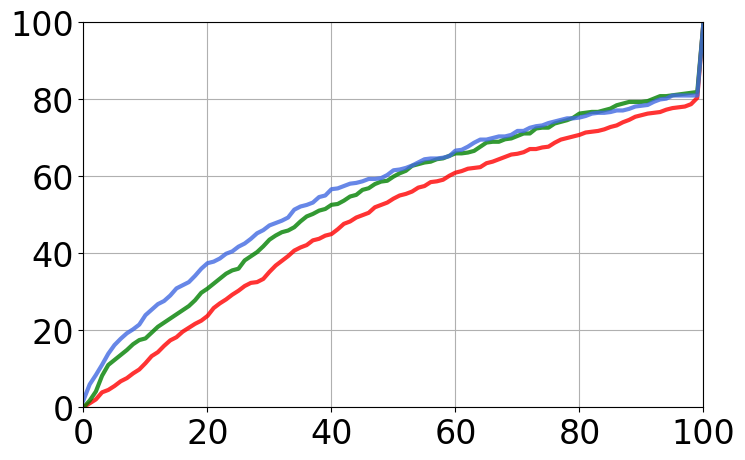

In [172]:
fig, ax4 = plt.subplots(1,1, figsize=(8,5))
plt.rcParams.update({'font.size':24})
dc_col = '15of30'
site_key = 'Carp'
actvt_key = 'high'
type_key = activity_types[actvt_key][site_key]
data_params['start'] = dt_starts[f'{site_key} {actvt_key}']
data_params['end'] = dt_ends[f'{site_key} {actvt_key}']
print(site_key, type_key)
data_params["site_tag"] = site_key
data_params["site_name"] = SITE_NAMES[site_key]
data_params["type_tag"] = type_key
data_params['detector_tag'] = 'bd2'
data_params['assembly_type'] = 'kmeans'
data_params['recording_start'] = '03:00'
data_params['recording_end'] = '13:00'
file_paths = get_file_paths(data_params)
p_settings = {'linestyle':'solid', 'linewidth':3}
data_params['P'] = 0.20
plot_all_single_dc_metric_curves(ax4, file_paths, dc_col, data_params, p_settings)
ax4.set_xlim(0, 100)
ax4.set_ylim(0, 100)
ax4.grid(which='both')

In [169]:
def get_percent_points_in_bounds_log(plt_dcmetr, plt_cmetr, p, upb):
    points_dc = pd.DataFrame(plt_dcmetr.values, columns=['values'], index=plt_dcmetr.index)
    points_c = pd.DataFrame(plt_cmetr.values, columns=['values'], index=plt_cmetr.index)
    points_c = points_c[points_c!=0].dropna()
    points_dc = points_dc.loc[points_c.index]
    total_num_points = points_dc.shape[0]

    axis = 1
    within_bounds = ((points_dc.values<=points_c.values*(axis+(upb*p)))&(points_dc.values>=points_c.values*(axis-p)))
    num_points_in_bounds = np.sum(within_bounds.astype(int), axis=0)
    percent_points_in_bounds = num_points_in_bounds / total_num_points
    # all_points_bound = p[percent_points_in_bounds==1][0]
    # test_true_100_at_factor(points_dc, points_c, all_points_bound)

    return percent_points_in_bounds

def test_true_100_at_factor(points_dc, points_c, p):
    test_dc = points_dc[points_dc!=0].dropna()
    test_c = points_c.loc[test_dc.index]
    filt_dc = (test_dc.values>test_c.values*(1+p))|(test_dc.values<test_c.values*(1-p))
    assert filt_dc.all()==False
    
def plot_percent_within_bounds_curve_for_metric(ax, plt_dc_metr, plt_c_metr, data_params):
    frac = float(re.findall(r"(\d.\d+)", plt_dc_metr.columns[0])[0])
    p = np.arange(0, 10, 0.01) + 1e-14
    p_inds = np.where(np.isclose(p, data_params['P'], atol=1e-6))[0][0]
    percent_points_in_bounds = get_percent_points_in_bounds_log(plt_dc_metr, plt_c_metr, p, 1.0)

    if data_params['metric_tag']=='call_rate':
        col = 'red'
    elif data_params['metric_tag']=='activity_index':
        col = 'royalblue'
    else:
        col = 'green'

    points_on_line = percent_points_in_bounds[p_inds]
    ax.plot(100*p, 100*percent_points_in_bounds, label=f'{round(100*points_on_line)}% captured',
                color=col, linewidth=3, alpha=0.8)

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    
def plot_indiv_dc_control_comp_over_cycle_linear_scale(ax, single_col_dc_metr1, single_col_c_metr, data_params):
    single_col_dc_metr1.index = pd.DatetimeIndex(single_col_dc_metr1.index)
    dc_metr1 = pd.pivot_table(single_col_dc_metr1, index=(single_col_dc_metr1.index.time), 
                        columns=single_col_dc_metr1.index.date, 
                        values=single_col_dc_metr1.columns[0])
    single_col_c_metr.index = pd.DatetimeIndex(single_col_c_metr.index)
    paired_col_c_metr = single_col_c_metr[(~single_col_dc_metr1.isna()).values]
    c_metr = pd.pivot_table(paired_col_c_metr, index=(paired_col_c_metr.index.time), 
                    columns=paired_col_c_metr.index.date, 
                    values=paired_col_c_metr.columns[0])
    ax.grid(which='both')
    if data_params['metric_tag']=='call_rate':
        col = 'red'
        units = 'calls/min'
    elif data_params['metric_tag']=='activity_index':
        col = 'royalblue'
        units = '%'
    else:
        col = 'green'
        units = '%'
    frac = float(re.findall(r"\d.\d+", single_col_dc_metr1.columns[0])[0])
    c_metr_max = c_metr.max().max()
    ax.plot([0, 100*c_metr_max], [0, 100*c_metr_max], linestyle='dashed', color='k', label='line-of-unity')
    
    ax.scatter(c_metr, dc_metr1, color=col, edgecolors='k', s=80, alpha=0.8)
    ax.set_xlabel(f'True values ({units})')
    ax.set_ylabel(f'Reduced estimate ({units})')
    upper_lim = 400
    if (data_params['metric_tag'] == 'call_rate'):
        ax.set_xlim(0, upper_lim)
        ax.set_ylim(0, upper_lim)
    else:
        ax.set_xlim(0, 100)
        ax.set_ylim(0, 100)
        ax.set_xticks(np.arange(0, 110, 20))
        ax.set_yticks(np.arange(0, 110, 20))